# Chama Station Inn Prototype Presentation Notebook

Use this notebook to present **current prototype value** to the client.

- Audience: owner + operators
- Focus: why this prototype should become the inn's operations PWA foundation


## Property & Brand Framing

- Boutique inn, approximately 9 rooms
- Brand direction: spa-like, calm, premium
- Experience direction: New Mexico-inspired room themes

The charts below are intentionally operator-focused so decision-makers can connect brand promise to operational execution.


In [1]:
from pathlib import Path
from math import cos, sin, pi
try:
    from IPython.display import SVG, Markdown, display
except Exception:
    def SVG(content):
        return content

    def Markdown(content):
        return content

    def display(content):
        print(content)


NOTEBOOK_DIR_CANDIDATES = [
    Path.cwd(),
    Path.cwd() / "docs" / "client-handoff" / "notebooks",
    Path("docs/client-handoff/notebooks"),
]
NOTEBOOK_DIR = next(
    (
        candidate.resolve()
        for candidate in NOTEBOOK_DIR_CANDIDATES
        if candidate.exists() and (candidate / "../assets").resolve().exists()
    ),
    Path.cwd().resolve(),
)


def resolve_notebook_path(path):
    target = Path(path)
    if target.is_absolute():
        return target

    return (NOTEBOOK_DIR / target).resolve()


def notebook_markdown_path(path):
    return Path(path).as_posix()

BRAND = {
    "bg": "#0f1115",
    "panel": "#1a2230",
    "text": "#e6edf7",
    "muted": "#9fb0c8",
    "accent": "#67b0ff",
    "accent2": "#69d2b0",
    "warn": "#f8c26a",
    "risk": "#f07c82",
}

def _svg_shell(width, height, body):
    return f"""<svg xmlns='http://www.w3.org/2000/svg' width='{width}' height='{height}' viewBox='0 0 {width} {height}'>
    <rect x='0' y='0' width='{width}' height='{height}' fill='{BRAND['bg']}' rx='14'/>
    {body}
    </svg>"""

def bar_chart_svg(title, labels, values, color="#67b0ff", width=980, height=420):
    max_v = max(values) if values else 1
    n = len(labels)
    left, top, chart_w, chart_h = 220, 70, width - 280, height - 120
    bar_h = chart_h / max(n, 1) * 0.62
    gap = chart_h / max(n, 1)
    parts = [f"<text x='24' y='38' fill='{BRAND['text']}' font-size='28' font-family='Arial' font-weight='700'>{title}</text>"]
    for i, (label, value) in enumerate(zip(labels, values)):
        y = top + i * gap
        w = 0 if max_v == 0 else (value / max_v) * chart_w
        parts.append(f"<text x='24' y='{y + bar_h*0.72:.1f}' fill='{BRAND['muted']}' font-size='17' font-family='Arial'>{label}</text>")
        parts.append(f"<rect x='{left}' y='{y:.1f}' width='{w:.1f}' height='{bar_h:.1f}' rx='8' fill='{color}' opacity='0.9'/>")
        parts.append(f"<text x='{left + w + 10:.1f}' y='{y + bar_h*0.72:.1f}' fill='{BRAND['text']}' font-size='16' font-family='Arial'>{value}</text>")
    return _svg_shell(width, height, "\n".join(parts))

def line_chart_svg(title, x_labels, y_values, color="#69d2b0", width=980, height=440):
    if not y_values:
        return _svg_shell(width, height, "")
    left, top, chart_w, chart_h = 80, 70, width - 150, height - 150
    min_v, max_v = min(y_values), max(y_values)
    span = (max_v - min_v) or 1
    points = []
    for i, v in enumerate(y_values):
        x = left + (i / max(len(y_values)-1,1)) * chart_w
        y = top + chart_h - ((v - min_v) / span) * chart_h
        points.append((x, y, v))
    poly = " ".join([f"{x:.1f},{y:.1f}" for x, y, _ in points])
    parts = [f"<text x='24' y='38' fill='{BRAND['text']}' font-size='28' font-family='Arial' font-weight='700'>{title}</text>"]
    parts.append(f"<polyline points='{poly}' fill='none' stroke='{color}' stroke-width='4'/>")
    for x, y, v in points:
        parts.append(f"<circle cx='{x:.1f}' cy='{y:.1f}' r='5' fill='{color}'/>")
        parts.append(f"<text x='{x+8:.1f}' y='{y-8:.1f}' fill='{BRAND['muted']}' font-size='13' font-family='Arial'>{v}</text>")
    for i, lbl in enumerate(x_labels):
        x = left + (i / max(len(x_labels)-1,1)) * chart_w
        parts.append(f"<text x='{x-15:.1f}' y='{height-32}' fill='{BRAND['muted']}' font-size='12' font-family='Arial'>{lbl}</text>")
    return _svg_shell(width, height, "\n".join(parts))

def donut_svg(title, value_pct, subtitle, width=520, height=360):
    cx, cy, r = 170, 190, 95
    pct = max(0, min(100, value_pct)) / 100
    end_angle = -pi/2 + 2*pi*pct
    x2 = cx + r * cos(end_angle)
    y2 = cy + r * sin(end_angle)
    large = 1 if pct > 0.5 else 0
    parts = [f"<text x='22' y='42' fill='{BRAND['text']}' font-size='24' font-family='Arial' font-weight='700'>{title}</text>"]
    parts.append(f"<circle cx='{cx}' cy='{cy}' r='{r}' fill='none' stroke='#2d3648' stroke-width='24'/>")
    if pct > 0:
        parts.append(f"<path d='M {cx} {cy-r} A {r} {r} 0 {large} 1 {x2:.1f} {y2:.1f}' fill='none' stroke='{BRAND['accent2']}' stroke-width='24' stroke-linecap='round'/>")
    parts.append(f"<text x='{cx-44}' y='{cy+10}' fill='{BRAND['text']}' font-size='34' font-family='Arial' font-weight='700'>{value_pct:.1f}%</text>")
    parts.append(f"<text x='22' y='{height-38}' fill='{BRAND['muted']}' font-size='16' font-family='Arial'>{subtitle}</text>")
    return _svg_shell(width, height, "\n".join(parts))

def show_image_if_exists(path, fallback_text):
    resolved = resolve_notebook_path(path)
    if resolved.exists():
        display(Markdown(f"![{resolved.name}]({notebook_markdown_path(path)})"))
    else:
        display(Markdown(f"**{fallback_text}**  \nExpected path: `{path}`"))


In [2]:
property_profile = {
    "name": "Chama Station Inn",
    "rooms": 9,
    "brand_direction": "Spa-like, calm, premium",
    "experience_motif": "New Mexico room themes",
    "current_public_site": "https://chamastationinn.com/",
}

prototype_kpis = {
    "Guests": 24,
    "Stays": 37,
    "Booked (Pipeline)": 14,
    "Checked In": 6,
    "Leads": 5,
    "Cancelled": 3,
    "Data Quality Issues": 9,
    "Contact Gaps (48h)": 1,
    "Contact Ready Rate (48h)": 75.0,
}

display(Markdown("### Snapshot"))
for k, v in property_profile.items():
    display(Markdown(f"- **{k.replace('_', ' ').title()}**: {v}"))


### Snapshot

- **Name**: Chama Station Inn

- **Rooms**: 9

- **Brand Direction**: Spa-like, calm, premium

- **Experience Motif**: New Mexico room themes

- **Current Public Site**: https://chamastationinn.com/

## Brand Context Images


In [3]:
show_image_if_exists("../assets/landing-page-current.png", "Landing page screenshot not found yet.")
show_image_if_exists("../assets/landing-page-placeholder.svg", "Using placeholder until screenshot is added.")
show_image_if_exists("../assets/prototype-ops-flow.svg", "Ops flow image missing.")


**Landing page screenshot not found yet.**  
Expected path: `../assets/landing-page-current.png`

![landing-page-placeholder.svg](../assets/landing-page-placeholder.svg)

![prototype-ops-flow.svg](../assets/prototype-ops-flow.svg)

## Pipeline and Data Quality Visuals


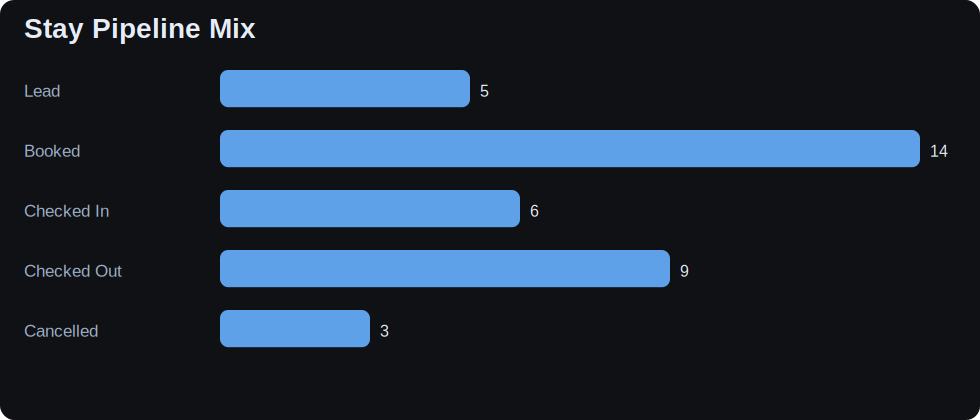

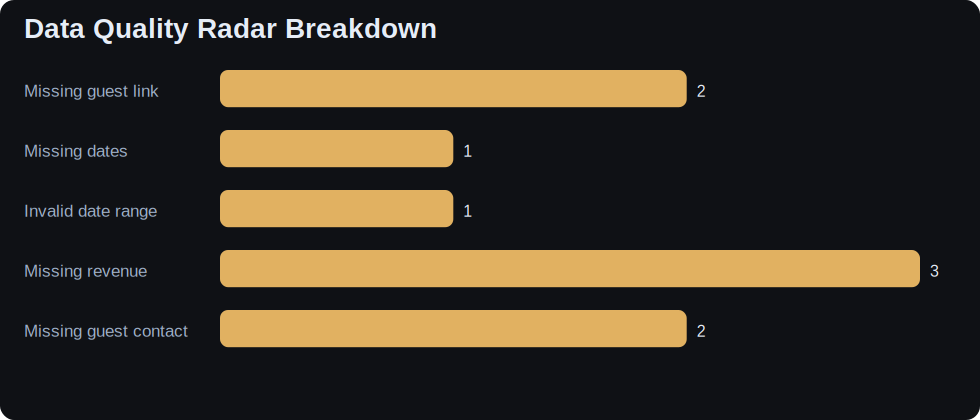

In [4]:
pipeline_labels = ["Lead", "Booked", "Checked In", "Checked Out", "Cancelled"]
pipeline_values = [5, 14, 6, 9, 3]

display(SVG(bar_chart_svg("Stay Pipeline Mix", pipeline_labels, pipeline_values, color=BRAND['accent'])))

quality_labels = [
    "Missing guest link",
    "Missing dates",
    "Invalid date range",
    "Missing revenue",
    "Missing guest contact",
]
quality_values = [2, 1, 1, 3, 2]

display(SVG(bar_chart_svg("Data Quality Radar Breakdown", quality_labels, quality_values, color=BRAND['warn'])))


## Arrival Readiness (48h)


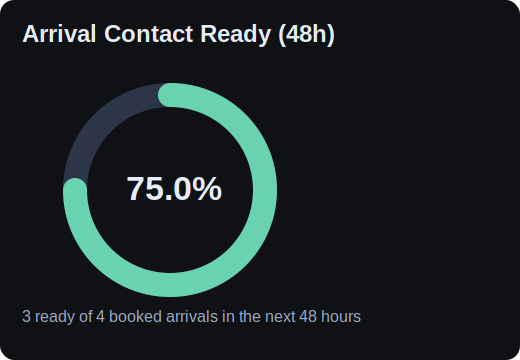

In [5]:
ready_rate = prototype_kpis["Contact Ready Rate (48h)"]
ready_count = 3
total_48h = 4

display(SVG(donut_svg(
    "Arrival Contact Ready (48h)",
    ready_rate,
    f"{ready_count} ready of {total_48h} booked arrivals in the next 48 hours"
)))


## 14-Day Occupancy Signal (Demo Projection)


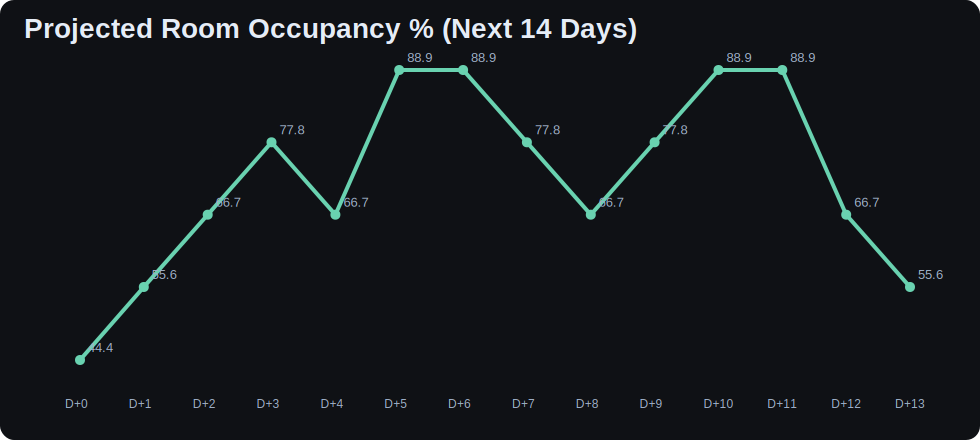

In [6]:
days = [f"D+{i}" for i in range(14)]
occupied_rooms = [4,5,6,7,6,8,8,7,6,7,8,8,6,5]
occupancy_pct = [round(v / property_profile['rooms'] * 100, 1) for v in occupied_rooms]

display(SVG(line_chart_svg(
    "Projected Room Occupancy % (Next 14 Days)",
    days,
    occupancy_pct,
    color=BRAND['accent2']
)))


## Auto-Generated Client Talking Points


In [7]:
talking_points = [
    "This prototype already supports operational control, not just website content.",
    f"Current 48h contact readiness is {ready_rate:.1f}%; improving this directly reduces arrival friction.",
    f"With only {property_profile['rooms']} rooms, each operational miss has outsized brand impact.",
    "WordPress-backed model is stable now and ready for phased PWA workflow lift-out.",
]
for i, point in enumerate(talking_points, start=1):
    display(Markdown(f"{i}. {point}"))


1. This prototype already supports operational control, not just website content.

2. Current 48h contact readiness is 75.0%; improving this directly reduces arrival friction.

3. With only 9 rooms, each operational miss has outsized brand impact.

4. WordPress-backed model is stable now and ready for phased PWA workflow lift-out.

## Study Prompts

- Which metric is the fastest confidence win for the owner?
- Which queue should be reviewed first on busy days?
- What language should be swapped in the term mapping workbook?
